In [1]:
import sklearn 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


path_dataset1 = r'C:\Users\abrau\uvic\seng474\seng474_Assignments\assignment3\files\dataset1.csv'
path_dataset2 = r'C:\Users\abrau\uvic\seng474\seng474_Assignments\assignment3\files\dataset2.csv'

dataset1 = pd.read_csv(path_dataset1, header=None).values # 2D dataset
dataset2 = pd.read_csv(path_dataset2, header=None).values # 3D dataset

c:\Users\abrau\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Function to plot dendrogram and decide the optimal number of clusters
def plot_dendrogram_and_decide_k(data, linkage_method, title, k):
    plt.figure(figsize=(10, 7))
    plt.title(title)
    
    # Perform hierarchical clustering and plot dendrogram
    linkage_matrix = linkage(data, method=linkage_method, metric='euclidean')
    dendrogram(linkage_matrix, truncate_mode='lastp', p=20)  # Show only the last 20 merged clusters
    
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    plt.show()

    optimal_k = k
    return optimal_k

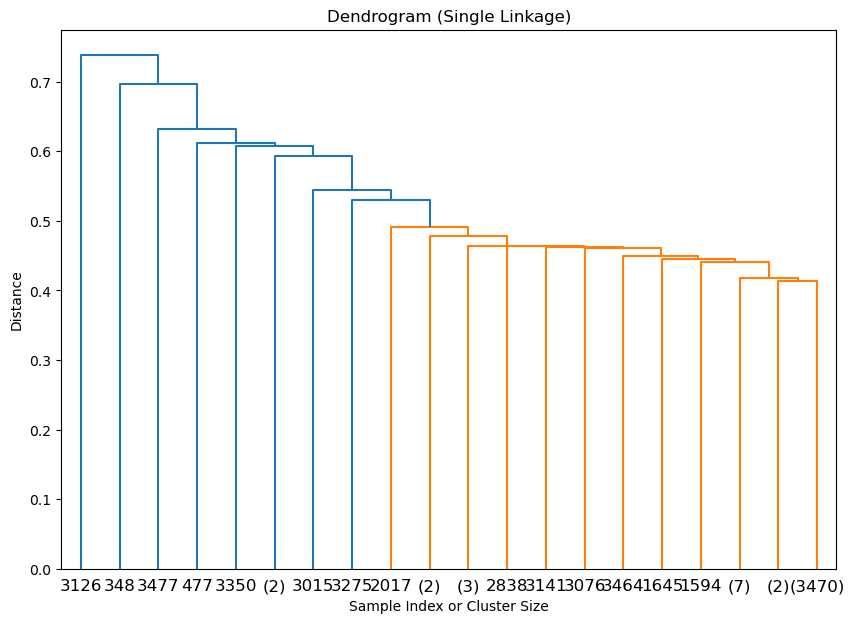

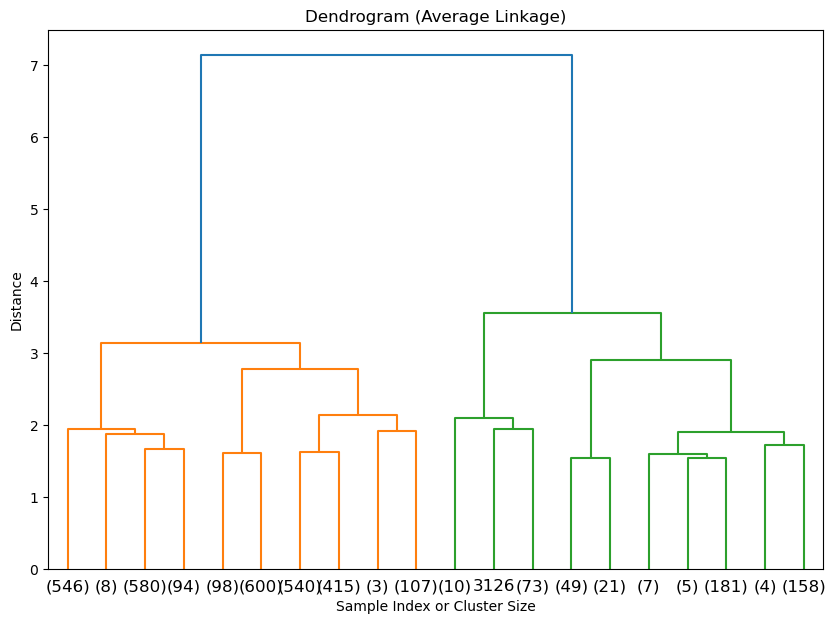

c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [3]:
k = 4

# Plot dendrogram for single linkage and decide k
optimal_k_single = plot_dendrogram_and_decide_k(dataset1, linkage_method='single', title='Dendrogram (Single Linkage)', k=k)

# Plot dendrogram for average linkage and decide k
optimal_k_average = plot_dendrogram_and_decide_k(dataset1, linkage_method='average', title='Dendrogram (Average Linkage)', k=k)

# Perform clustering with the optimal k for single linkage
cluster_single = AgglomerativeClustering(n_clusters=optimal_k_single, linkage='single', affinity='euclidean')
labels_single = cluster_single.fit_predict(dataset1)

# Perform clustering with the optimal k for average linkage
cluster_average = AgglomerativeClustering(n_clusters=optimal_k_average, linkage='average', affinity='euclidean')
labels_average = cluster_average.fit_predict(dataset1)

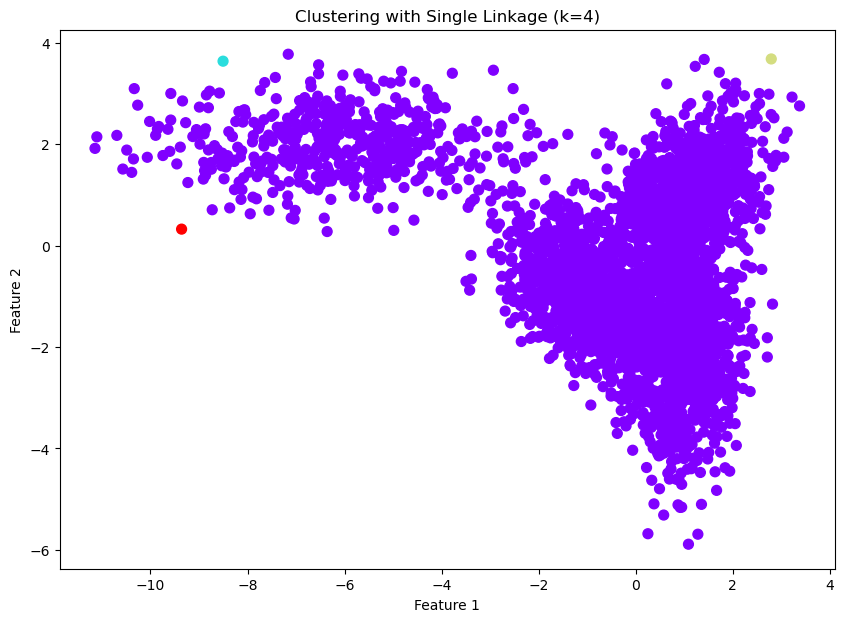

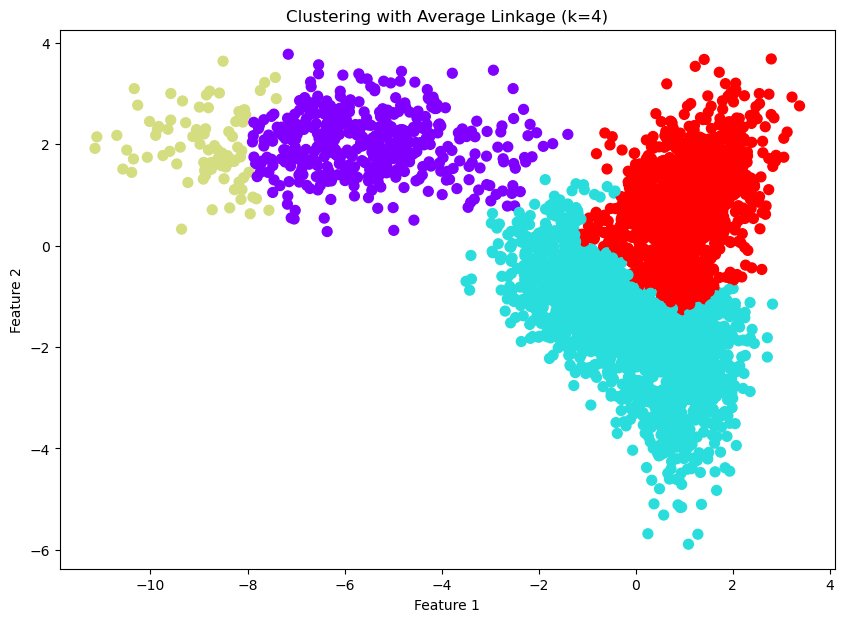

In [4]:
# Plot clustering results for single linkage
plt.figure(figsize=(10, 7))
plt.scatter(dataset1[:, 0], dataset1[:, 1], c=labels_single, cmap='rainbow', s=50)
plt.title(f'Clustering with Single Linkage (k={optimal_k_single})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Plot clustering results for average linkage
plt.figure(figsize=(10, 7))
plt.scatter(dataset1[:, 0], dataset1[:, 1], c=labels_average, cmap='rainbow', s=50)
plt.title(f'Clustering with Average Linkage (k={optimal_k_average})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

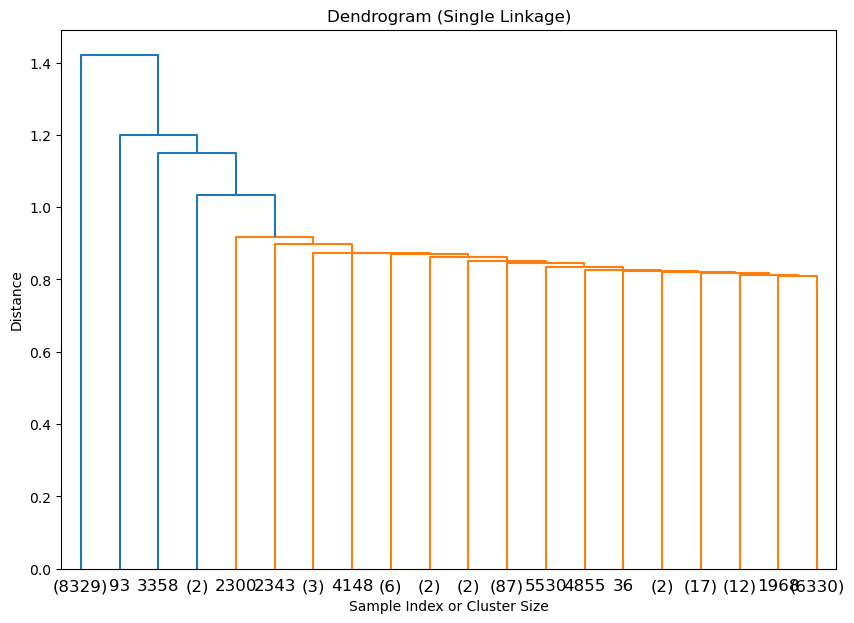

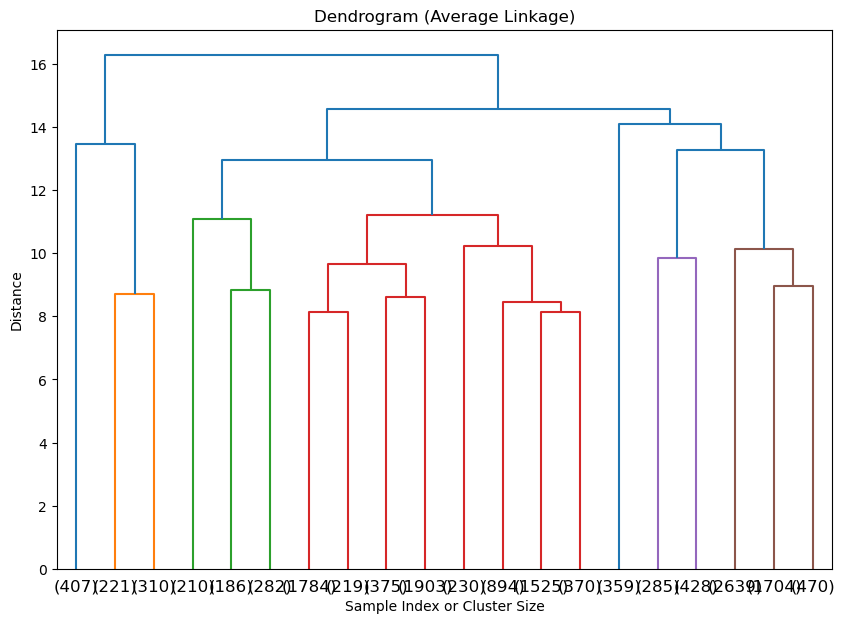

c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(
c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


In [5]:
k = 2

# Plot dendrogram for single linkage and decide k
optimal_k_single = plot_dendrogram_and_decide_k(dataset2, linkage_method='single', title='Dendrogram (Single Linkage)', k=k)

# Plot dendrogram for average linkage and decide k
optimal_k_average = plot_dendrogram_and_decide_k(dataset2, linkage_method='average', title='Dendrogram (Average Linkage)', k=k)

# Perform clustering with the optimal k for single linkage
cluster_single = AgglomerativeClustering(n_clusters=optimal_k_single, linkage='single', affinity='euclidean')
labels_single = cluster_single.fit_predict(dataset2)

# Perform clustering with the optimal k for average linkage
cluster_average = AgglomerativeClustering(n_clusters=optimal_k_average, linkage='average', affinity='euclidean')
labels_average = cluster_average.fit_predict(dataset2)

In [6]:
import plotly.express as px

# Function to plot 3D clustering results interactively using Plotly
def plot_3d_clustering_interactive(data, labels, title):
    # Create a DataFrame for Plotly
    df = pd.DataFrame(data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
    df['Cluster'] = labels  # Add cluster labels to the DataFrame
    
    # Create an interactive 3D scatter plot
    fig = px.scatter_3d(df, x='Feature 1', y='Feature 2', z='Feature 3', color='Cluster',
                        title=title, color_continuous_scale='rainbow')
    fig.update_traces(marker=dict(size=5))  # Adjust marker size
    fig.show()

# Plot clustering results for single linkage
plot_3d_clustering_interactive(dataset2, labels_single, f'Clustering with Single Linkage (k={optimal_k_single})')

# Plot clustering results for average linkage
plot_3d_clustering_interactive(dataset2, labels_average, f'Clustering with Average Linkage (k={optimal_k_average})')

In [8]:
def decide_k_automatically(linkage_matrix, max_clusters=10):
    distances = linkage_matrix[:, 2]  # Extract the linkage distances
    diffs = np.diff(distances)  # Compute the difference between consecutive distances

    # Find the index where the largest jump in distance occurs
    elbow_index = np.argmax(diffs) + 1  # +1 because np.diff reduces array length by 1
    optimal_k = len(distances) - elbow_index + 1

    # Ensure optimal_k is within a reasonable range
    optimal_k = min(optimal_k, max_clusters)
    return optimal_k

# Function to perform clustering and plot results
def perform_clustering_and_plot(data, optimal_k_single, optimal_k_average, is_3d=False):
    # Perform clustering with the optimal k for single linkage
    cluster_single = AgglomerativeClustering(n_clusters=optimal_k_single, linkage='single', affinity='euclidean')
    labels_single = cluster_single.fit_predict(data)

    # Perform clustering with the optimal k for average linkage
    cluster_average = AgglomerativeClustering(n_clusters=optimal_k_average, linkage='average', affinity='euclidean')
    labels_average = cluster_average.fit_predict(data)

    # Function to plot clustering results interactively using Plotly
    def plot_clustering_interactive(data, labels, title):
        if is_3d:
            # Create a DataFrame for 3D data
            df = pd.DataFrame(data, columns=['Feature 1', 'Feature 2', 'Feature 3'])
            df['Cluster'] = labels  # Add cluster labels to the DataFrame
            
            # Create an interactive 3D scatter plot
            fig = px.scatter_3d(df, x='Feature 1', y='Feature 2', z='Feature 3', color='Cluster',
                                title=title, color_continuous_scale='rainbow')
        else:
            # Create a DataFrame for 2D data
            df = pd.DataFrame(data, columns=['Feature 1', 'Feature 2'])
            df['Cluster'] = labels  # Add cluster labels to the DataFrame
            
            # Create an interactive 2D scatter plot
            fig = px.scatter(df, x='Feature 1', y='Feature 2', color='Cluster',
                             title=title, color_continuous_scale='rainbow')
        
        fig.update_traces(marker=dict(size=5))  # Adjust marker size
        fig.show()

    # Plot clustering results for single linkage
    plot_clustering_interactive(data, labels_single, f'Clustering with Single Linkage (k={optimal_k_single})')

    # Plot clustering results for average linkage
    plot_clustering_interactive(data, labels_average, f'Clustering with Average Linkage (k={optimal_k_average})')

# Function to plot dendrogram and decide the optimal number of clusters
def plot_dendrogram(data, linkage_method, title):
    plt.figure(figsize=(10, 7))
    plt.title(title)
    
    # Perform hierarchical clustering and plot dendrogram
    linkage_matrix = linkage(data, method=linkage_method, metric='euclidean')
    dendrogram(linkage_matrix, truncate_mode='lastp', p=20)  # Show only the last 20 merged clusters
    
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    plt.show()

    return linkage_matrix

Analyzing 2D Dataset (dataset1):


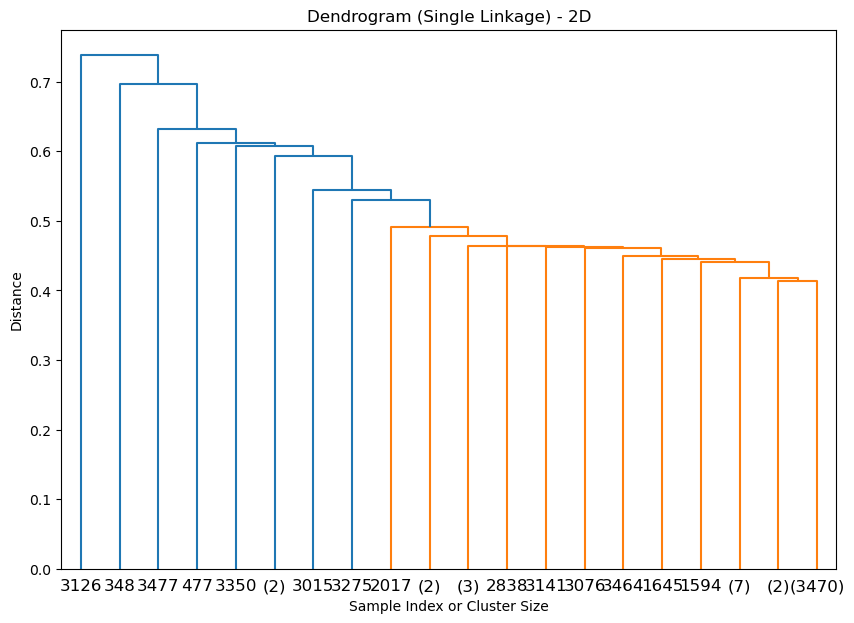

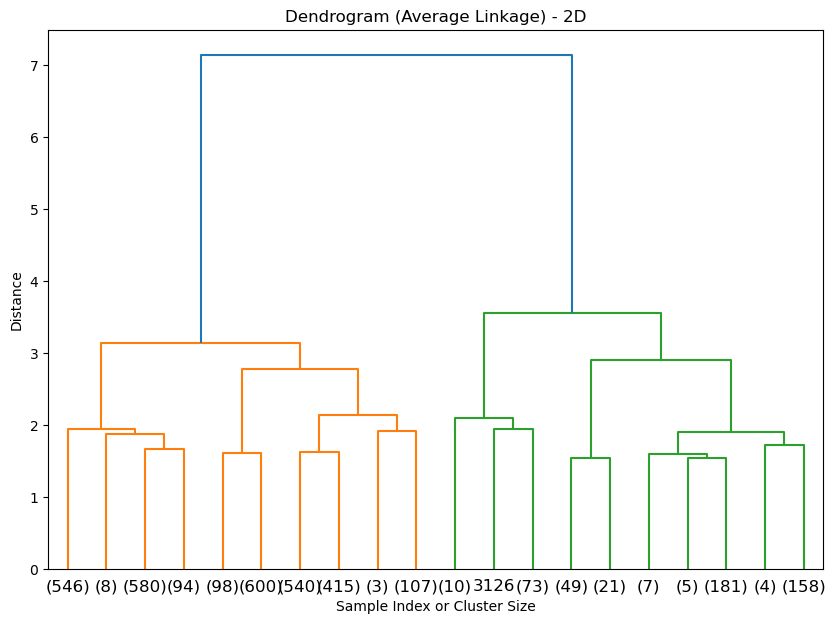

Optimal k for 2D Dataset (Single Linkage): 3
Optimal k for 2D Dataset (Average Linkage): 2


c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead

c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead



In [9]:
# Analyze dataset1 (2D)
print("Analyzing 2D Dataset (dataset1):")
linkage_matrix_single_2D = plot_dendrogram(dataset1, linkage_method='single', title='Dendrogram (Single Linkage) - 2D')
linkage_matrix_average_2D = plot_dendrogram(dataset1, linkage_method='average', title='Dendrogram (Average Linkage) - 2D')

optimal_k_single_2D = decide_k_automatically(linkage_matrix_single_2D)
optimal_k_average_2D = decide_k_automatically(linkage_matrix_average_2D)

print(f"Optimal k for 2D Dataset (Single Linkage): {optimal_k_single_2D}")
print(f"Optimal k for 2D Dataset (Average Linkage): {optimal_k_average_2D}")

perform_clustering_and_plot(dataset1, optimal_k_single_2D, optimal_k_average_2D, is_3d=False)


Analyzing 3D Dataset (dataset2):


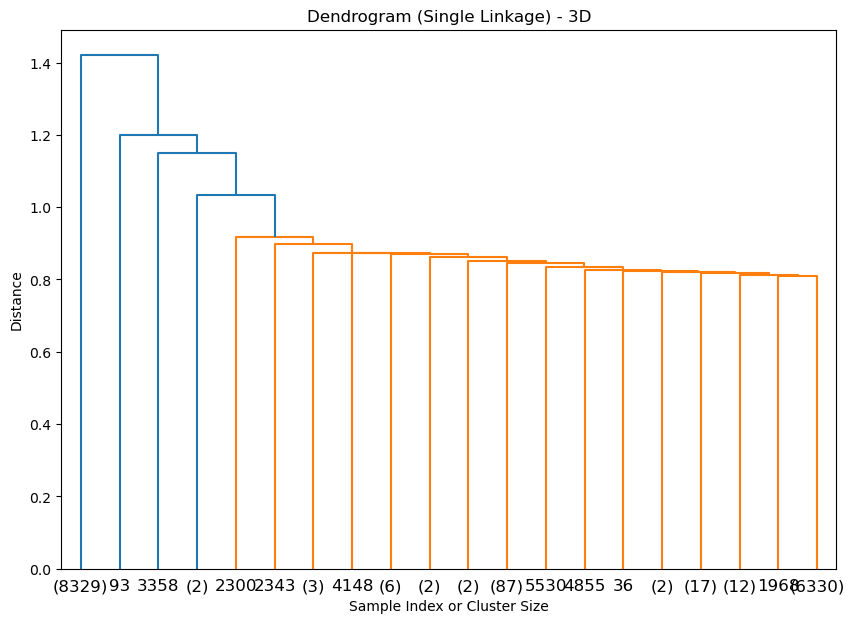

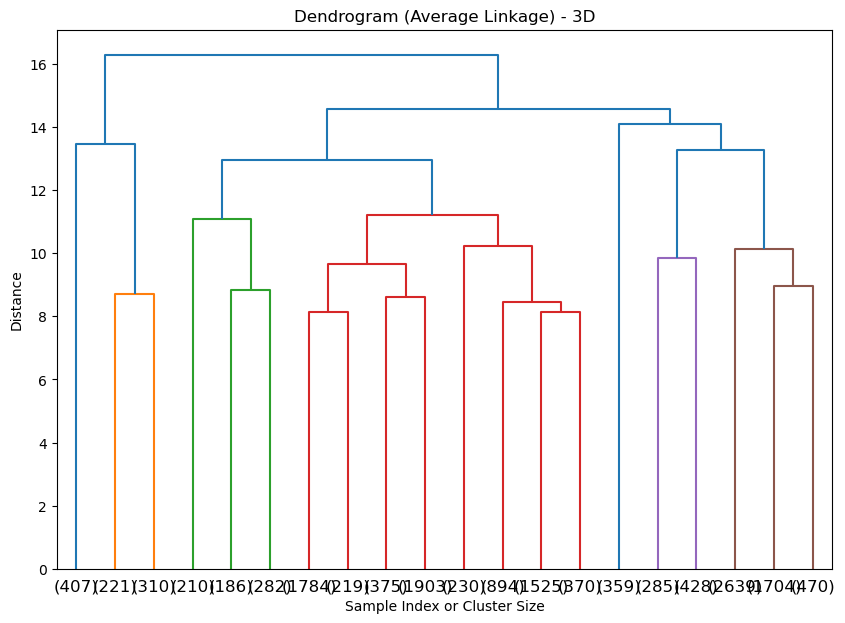

Optimal k for 3D Dataset (Single Linkage): 2
Optimal k for 3D Dataset (Average Linkage): 7


c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead

c:\Users\abrau\anaconda3\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning:

Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead



In [10]:
# Analyze dataset2 (3D)
print("\nAnalyzing 3D Dataset (dataset2):")
linkage_matrix_single_3D = plot_dendrogram(dataset2, linkage_method='single', title='Dendrogram (Single Linkage) - 3D')
linkage_matrix_average_3D = plot_dendrogram(dataset2, linkage_method='average', title='Dendrogram (Average Linkage) - 3D')

optimal_k_single_3D = decide_k_automatically(linkage_matrix_single_3D)
optimal_k_average_3D = decide_k_automatically(linkage_matrix_average_3D)

print(f"Optimal k for 3D Dataset (Single Linkage): {optimal_k_single_3D}")
print(f"Optimal k for 3D Dataset (Average Linkage): {optimal_k_average_3D}")

perform_clustering_and_plot(dataset2, optimal_k_single_3D, optimal_k_average_3D, is_3d=True)